In [3]:
# KMeans Clustering on Iris Dataset
import numpy as np

np.random.seed(1)
from sklearn import cluster, datasets

X_iris, y_iris = datasets.load_iris(return_X_y=True)

k_means = cluster.KMeans(n_clusters=3)
k_means.fit(X_iris)
print(k_means.labels_[::10])
print(y_iris[::10])

[1 1 1 1 1 2 0 0 0 0 2 2 2 2 2]
[0 0 0 0 0 1 1 1 1 1 2 2 2 2 2]


In [2]:
# KMeans Vector Quantization on Raccoon Face
import numpy as np
np.random.seed(1)
from sklearn import cluster
import scipy as sp

try:
    face = sp.face(gray=True)
except:
    from scipy import datasets # scipy.misc deprecated, use datasets instead
    face = datasets.face(gray=True)
X = face.reshape((-1, 1)) # Need (n_sample, n_feature) array
k_means = cluster.KMeans(n_clusters=5, n_init=1)
k_means.fit(X)

values = k_means.cluster_centers_.squeeze()
labels = k_means.labels_
face_compressed = np.choose(labels, values)
face_compressed.reshape(face.shape)

array([[116.93734808, 116.93734808, 155.30249952, ..., 116.93734808,
        116.93734808, 155.30249952],
       [ 77.32292075, 116.93734808, 116.93734808, ..., 116.93734808,
        116.93734808, 155.30249952],
       [ 77.32292075,  77.32292075, 116.93734808, ..., 116.93734808,
        116.93734808, 155.30249952],
       ...,
       [116.93734808, 116.93734808, 116.93734808, ..., 155.30249952,
        155.30249952, 155.30249952],
       [ 77.32292075, 116.93734808, 116.93734808, ..., 155.30249952,
        155.30249952, 155.30249952],
       [ 77.32292075, 116.93734808, 116.93734808, ..., 155.30249952,
        155.30249952, 155.30249952]], shape=(768, 1024))

In [6]:
# Connectivity-Constrained Clustering on Coins
import numpy as np
np.random.seed(1)
from skimage.data import coins
from scipy.ndimage import gaussian_filter
from skimage.transform import rescale
from sklearn.feature_extraction import grid_to_graph
from sklearn.cluster import AgglomerativeClustering

rescaled_coins = rescale(gaussian_filter(coins(), sigma=2), 0.2, mode='reflect', anti_aliasing=False)
X = np.reshape(rescaled_coins, (-1, 1))

connectivity = grid_to_graph(*rescaled_coins.shape)

n_clusters = 27 # number of regions
ward = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward', connectivity=connectivity)
ward.fit(X)
label = np.reshape(ward.labels_, rescaled_coins.shape)

In [8]:
# Feature Agglomeration on Digits
import numpy as np
np.random.seed(1)
from sklearn import cluster, datasets
from sklearn.feature_extraction import grid_to_graph

digits = datasets.load_digits()
images = digits.images
X = np.reshape(images, (len(images), -1))
connectivity = grid_to_graph(*images[0].shape)

agglo = cluster.FeatureAgglomeration(connectivity=connectivity, n_clusters=32)
agglo.fit(X)
X_reduced = agglo.transform(X)

X_approx = agglo.inverse_transform(X_reduced)
images_approx = np.reshape(X_approx, images.shape)

[2.7325821  0.75607076 0.        ]


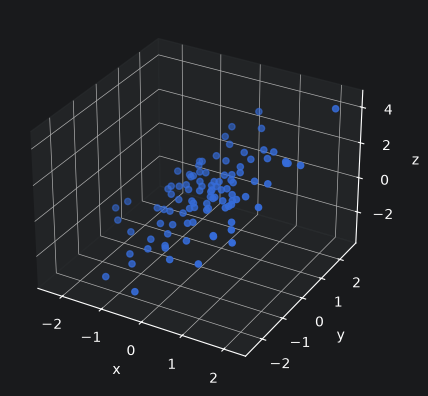

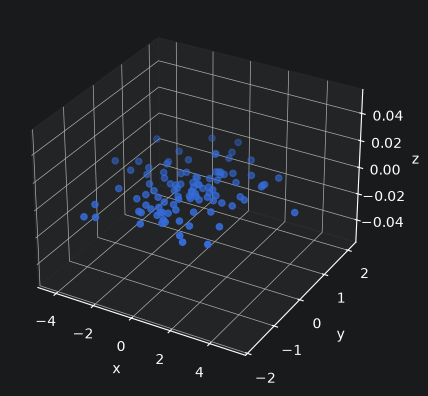

In [18]:
# PCA Decomposition
import numpy as np
np.random.seed(1)
import matplotlib.pyplot as plt
from sklearn import decomposition

x1 = np.random.normal(size=(100, 1))
x2 = np.random.normal(size=(100, 1))
x3 = x1 + x2
X = np.concatenate([x1, x2, x3], axis=1)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, 0], X[:, 1], X[:, 2])
_ = ax.set(xlabel='x', ylabel='y', zlabel='z')

pca = decomposition.PCA()
pca.fit(X)
print(pca.explained_variance_)

pca.set_params(n_components=2)
X_reduced=pca.fit_transform(X)
X_reduced.shape
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_reduced[:, 0], X_reduced[:, 1])
_ = ax.set(xlabel='x', ylabel='y', zlabel='z')

In [19]:
# ICA Decomposition
import numpy as np
np.random.seed(1)
import matplotlib.pyplot as plt
from sklearn import decomposition
from scipy import signal

time = np.linspace(0, 10, 2000)
s1 = np.sin(2*time) # Signal 1: sinusoidal signal
s2 = np.sign(np.sin(3 * time)) # Signal 2: square signal
s3 = signal.sawtooth(2 * np.pi * time) # Signal 3: saw tooth signal

S = np.c_[s1, s2, s3]
S += 0.2 * np.random.normal(size=S.shape) # Add noise
S /= S.std(axis=0) # Standardize data
# Mix data
A = np.array([[1, 1, 1], [0.5, 2, 1], [1.5, 1, 2]]) # Mixing matrix
X = np.dot(S, A.T) # Generate observations

# Compute ICA
ica = decomposition.FastICA()
S_ = ica.fit_transform(X) # Get estimated sources
A_ = ica.mixing_.T
np.allclose(X, np.dot(S_, A_) + ica.mean_)

True